# Part 1 — Explore, Preprocess & EDA

**Goal:** Clean the hotel sensor data, engineer occupancy-relevant features, and perform EDA to understand what occupied vs. unoccupied rooms look like.

**Preprocessing** (Stages A–D) was completed in `phase1_cleaning.ipynb` and saved to `final_cleaned_phase1.csv`.  
This notebook covers:
1. Cleaning summary
2. Reshape to wide format
3. Feature engineering
4. EDA — occupied vs unoccupied comparison
5. Unsupervised analysis (K-means, UMAP, t-SNE)

In [1]:
!pip install -q umap-learn seaborn matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import umap

# --- Plot style ---
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
})

COLORS = {'occupied': '#e74c3c', 'unoccupied': '#3498db', 'uncertain': '#95a5a6'}
print('Imports OK')

Imports OK


## 1. Load Cleaned Data

In [3]:
CLEANED_PATH = "/Users/phasurab/Desktop/Alto_test/final_cleaned_phase1.csv"

long_df = pd.read_csv(
    CLEANED_PATH,
    usecols=['timestamp', 'room_area', 'resolved_sensor_type',
             'quality_flag', 'imputed_value', 'outlier_flag', 'n_candidates'],
    dtype={
        'imputed_value': 'float32',
    },
    parse_dates=['timestamp'],
    low_memory=True,
)

for col in ['room_area', 'resolved_sensor_type', 'quality_flag']:
    long_df[col] = long_df[col].astype('category')

print(f"Loaded {long_df.shape[0]:,} rows, {long_df.shape[1]} columns")
print(f"Unique rooms: {long_df['room_area'].nunique()}")
print(f"Time range: {long_df['timestamp'].min()} → {long_df['timestamp'].max()}")
long_df.head(3)

Loaded 53,311,104 rows, 7 columns
Unique rooms: 482
Time range: 2025-12-01 00:00:00 → 2026-02-15 23:55:00


,timestamp,room_area,resolved_sensor_type,quality_flag,outlier_flag,imputed_value,n_candidates
0,2025-12-01 00:00:00,room_1001_bedroom,CO2,matched_original,False,502.0,1
1,2025-12-01 00:05:00,room_1001_bedroom,CO2,matched_original,False,504.0,1
2,2025-12-01 00:10:00,room_1001_bedroom,CO2,matched_original,False,506.0,1


## 2. Cleaning Summary

Summarise the preprocessing results from the cleaning pipeline.

=== Quality Flag Distribution ===
  single_candidate_misplaced                  23,900,221  (44.83%)
  multi_candidate_ambiguous                   10,482,019  (19.66%)
  multi_candidate_keep_original                9,409,921  (17.65%)
  matched_original                             9,366,241  (17.57%)
  invalid_all_thresholds                         148,078  ( 0.28%)
  missing                                          4,624  ( 0.01%)

=== Outlier Counts by Sensor ===
  temp              1,349,068
  CO2                 918,998
  RH                  907,295



=== Missing % After Imputation (per sensor) ===
  CO2               0.00%
  Motion            0.00%
  Presence          0.00%
  RH                0.00%
  temp              0.00%


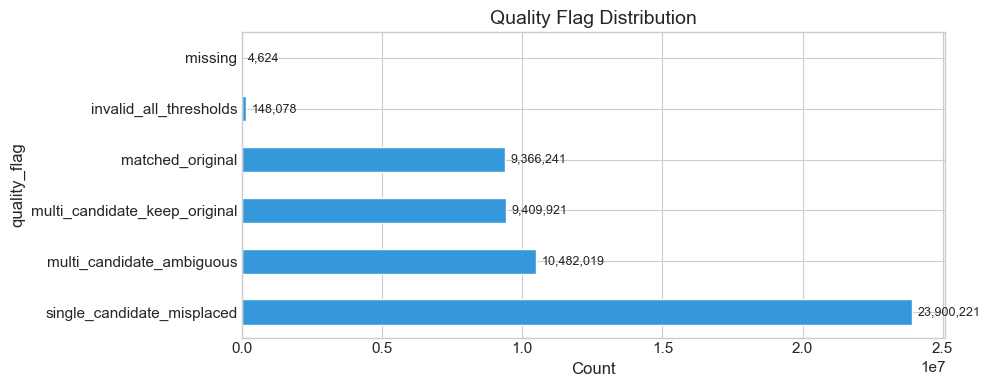

In [4]:
# --- 2a. Quality flag distribution ---
qf = long_df['quality_flag'].value_counts(dropna=False)
qf_pct = (qf / qf.sum() * 100).round(2)
print("=== Quality Flag Distribution ===")
for flag, cnt in qf.items():
    print(f"  {str(flag):40s}  {cnt:>12,}  ({qf_pct[flag]:5.2f}%)")

# --- 2b. Outlier counts by resolved sensor ---
out_counts = (
    long_df[long_df['outlier_flag'] == True]
    .groupby('resolved_sensor_type', observed=True)
    .size()
    .sort_values(ascending=False)
)
print("\n=== Outlier Counts by Sensor ===")
for sensor, cnt in out_counts.items():
    print(f"  {sensor:15s}  {cnt:>10,}")

# --- 2c. Missing ratio per sensor ---
valid_rows = long_df[long_df['resolved_sensor_type'].notna()]
miss = (
    valid_rows.groupby('resolved_sensor_type', observed=True)['imputed_value']
    .apply(lambda s: s.isna().mean() * 100)
    .sort_values(ascending=False)
)
print("\n=== Missing % After Imputation (per sensor) ===")
for sensor, pct in miss.items():
    print(f"  {sensor:15s}  {pct:5.2f}%")

# --- 2d. Quality flag bar chart ---
fig, ax = plt.subplots(figsize=(10, 4))
qf.plot.barh(ax=ax, color='#3498db', edgecolor='white')
ax.set_xlabel('Count')
ax.set_title('Quality Flag Distribution')
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=4, fontsize=9)
plt.tight_layout()
plt.show()

## 3. Pivot Long → Wide

Reshape to one row per `(timestamp, room_area)` with columns: RH, CO2, temp, Motion, Presence.

In [5]:
# Keep only rows with a valid resolved sensor type
valid = long_df[long_df['resolved_sensor_type'].notna()].copy()
print(f"Rows for pivot: {len(valid):,}")

wide = valid.pivot_table(
    index=['timestamp', 'room_area'],
    columns='resolved_sensor_type',
    values='imputed_value',
    aggfunc='first',
    observed=True,
).reset_index()

wide.columns.name = None  # flatten column index

# Free memory
del long_df, valid
gc.collect()

print(f"Wide shape: {wide.shape}")
print(f"Columns: {list(wide.columns)}")
wide.head()

Rows for pivot: 42,676,383


Wide shape: (10688832, 7)
Columns: ['timestamp', 'room_area', 'CO2', 'Motion', 'Presence', 'RH', 'temp']


,timestamp,room_area,CO2,Motion,Presence,RH,temp
0,2025-12-01,room_1001_bedroom,502.0,0.0,0.0,58.0,23.000000
1,2025-12-01,room_1002_bedroom,728.0,1.0,1.0,64.0,21.844999
2,2025-12-01,room_1003_bedroom,400.0,0.0,1.0,56.0,23.625000
3,2025-12-01,room_1004_bedroom,879.0,0.0,1.0,56.0,24.725000
4,2025-12-01,room_1005_bedroom,481.0,0.0,0.0,59.0,24.254999


## 4. Occupancy Labels & Feature Engineering

**Occupancy label:** Based on `presence_state` (ground truth per data dictionary).

| Presence Value | Label | Meaning |
|:---:|:---|:---|
| 1 | occupied | Guest present |
| 0 | unoccupied | No guest |
| 3 | sensor_disconnected | CO2 sensor offline |
| 4 | sensor_disconnected | Motion sensor offline |
| NaN | unknown | No data |

**Features:** lags, diffs, rolling stats, steps-since-event, cyclic time.

In [6]:
eda_feat = wide.sort_values(['room_area', 'timestamp']).reset_index(drop=True)
del wide
gc.collect()

# ===================== Occupancy label =====================
eda_feat['occupancy'] = np.select(
    [
        eda_feat['Presence'] == 1,
        eda_feat['Presence'] == 0,
        eda_feat['Presence'].isin([3, 4]),
    ],
    ['occupied', 'unoccupied', 'sensor_disconnected'],
    default=''
)
eda_feat.loc[eda_feat['occupancy'] == '', 'occupancy'] = np.nan
eda_feat['occupancy'] = eda_feat['occupancy'].astype('category')

# Binary occupancy (for numeric features)
eda_feat['occ_binary'] = np.where(
    eda_feat['Presence'] == 1, 1.0,
    np.where(eda_feat['Presence'] == 0, 0.0, np.nan)
).astype('float32')

# ===================== Time features =====================
eda_feat['hour'] = eda_feat['timestamp'].dt.hour.astype('int8')
eda_feat['dayofweek'] = eda_feat['timestamp'].dt.dayofweek.astype('int8')
eda_feat['is_night'] = ((eda_feat['hour'] >= 22) | (eda_feat['hour'] < 7)).astype('int8')
eda_feat['hour_sin'] = np.sin(2 * np.pi * eda_feat['hour'] / 24).astype('float32')
eda_feat['hour_cos'] = np.cos(2 * np.pi * eda_feat['hour'] / 24).astype('float32')

# ===================== Per-room temporal features =====================
g = eda_feat.groupby('room_area', observed=True)

# Lags
for col in ['RH', 'CO2', 'temp']:
    eda_feat[f'{col}_lag1'] = g[col].shift(1).astype('float32')
eda_feat['CO2_lag3'] = g['CO2'].shift(3).astype('float32')

# Diffs (1-step slope)
for col in ['RH', 'CO2', 'temp']:
    eda_feat[f'{col}_diff1'] = g[col].diff(1).astype('float32')

# Rolling stats (window=6 → 30 min at 5-min intervals)
W = 6
for col in ['CO2', 'temp', 'RH']:
    eda_feat[f'{col}_roll_mean_6'] = g[col].transform(
        lambda x: x.rolling(W, min_periods=1).mean()
    ).astype('float32')

eda_feat['CO2_roll_std_6'] = g['CO2'].transform(
    lambda x: x.rolling(W, min_periods=1).std()
).astype('float32')

# Motion rolling max (recent activity in 30-min window)
eda_feat['motion_roll_max_6'] = g['Motion'].transform(
    lambda x: x.rolling(W, min_periods=1).max()
).astype('float32')

# Presence rolling max (using binary occupied signal)
eda_feat['presence_roll_max_6'] = g['occ_binary'].transform(
    lambda x: x.rolling(W, min_periods=1).max()
).astype('float32')

# Steps since last event
def _steps_since(s, condition_fn):
    """Count timesteps since last active event within each room."""
    active = condition_fn(s)
    grps = active.cumsum()
    return grps.groupby(grps).cumcount()

eda_feat['steps_since_motion'] = g['Motion'].transform(
    lambda s: _steps_since(s, lambda x: x.fillna(0).gt(0))
).astype('float32')

eda_feat['steps_since_presence'] = g['Presence'].transform(
    lambda s: _steps_since(s, lambda x: x.fillna(0).eq(1))
).astype('float32')

# ===================== Occupancy proxy (supplementary) =====================
recent_motion = eda_feat['motion_roll_max_6'].gt(0)
co2_rising = eda_feat['CO2_diff1'].gt(0)

eda_feat['occupancy_proxy'] = np.select(
    [
        (eda_feat['Presence'] == 1) | (recent_motion.fillna(False) & eda_feat['CO2'].gt(600) & co2_rising.fillna(False)),
        (eda_feat['Presence'] == 0) & (~recent_motion.fillna(True)) & (eda_feat['CO2'].lt(500)),
    ],
    ['occupied', 'unoccupied'],
    default=''
)
eda_feat.loc[eda_feat['occupancy_proxy'] == '', 'occupancy_proxy'] = np.nan
eda_feat['occupancy_proxy'] = eda_feat['occupancy_proxy'].astype('category')

gc.collect()

print(f"eda_feat shape: {eda_feat.shape}")
print(f"\nOccupancy label distribution:")
print(eda_feat['occupancy'].value_counts(dropna=False))
print(f"\nOccupancy proxy distribution:")
print(eda_feat['occupancy_proxy'].value_counts(dropna=False))

eda_feat shape: (10688832, 30)

Occupancy label distribution:
occupancy
NaN                    4963853
occupied               2366081
unoccupied             2297469
sensor_disconnected    1061429
Name: count, dtype: int64

Occupancy proxy distribution:
occupancy_proxy
NaN           7198881
occupied      2644398
unoccupied     845553
Name: count, dtype: int64


## 5. Occupied vs Unoccupied — Summary Statistics

In [7]:
# Only compare definitive occupied vs unoccupied
mask_occ = eda_feat['occupancy'].isin(['occupied', 'unoccupied'])
compare = eda_feat.loc[mask_occ].copy()

stat_cols = ['RH', 'CO2', 'temp', 'CO2_diff1', 'motion_roll_max_6',
             'steps_since_motion', 'steps_since_presence',
             'CO2_roll_std_6', 'is_night']

summary = compare.groupby('occupancy', observed=True)[stat_cols].agg(
    ['mean', 'median', 'std']
).round(2)

print("=== Occupied vs Unoccupied — Feature Statistics ===")
summary

=== Occupied vs Unoccupied — Feature Statistics ===


RH                      CO2                          temp  \
                 mean median   std        mean median         std       mean   
occupancy                                                                      
occupied    62.770000   62.0  5.74  736.169983  682.0  255.759995  22.709999   
unoccupied  62.310001   62.0  5.79  598.179993  537.0  215.490005  22.840000   

                        CO2_diff1  ... steps_since_motion  \
           median   std      mean  ...                std   
occupancy                          ...                      
occupied     23.0  1.43      1.56  ...        2213.679932   
unoccupied   23.0  1.44     -1.67  ...        2880.340088   

           steps_since_presence                    CO2_roll_std_6         \
                           mean median         std           mean median   
occupancy                                                                  
occupied               0.000000    0.0    0.000000          14.90   7.90   
unoccupied           110.839996   22.0  616.890015          10.25   5.35   

                      is_night               
                  std     mean median   std  
occupancy                                    
occupied    20.280001     0.42    0.0  0.49  
unoccupied  15.510000     0.33    0.0  0.47  

[2 rows x 27 columns]

## 6. Distribution Plots — Occupied vs Unoccupied

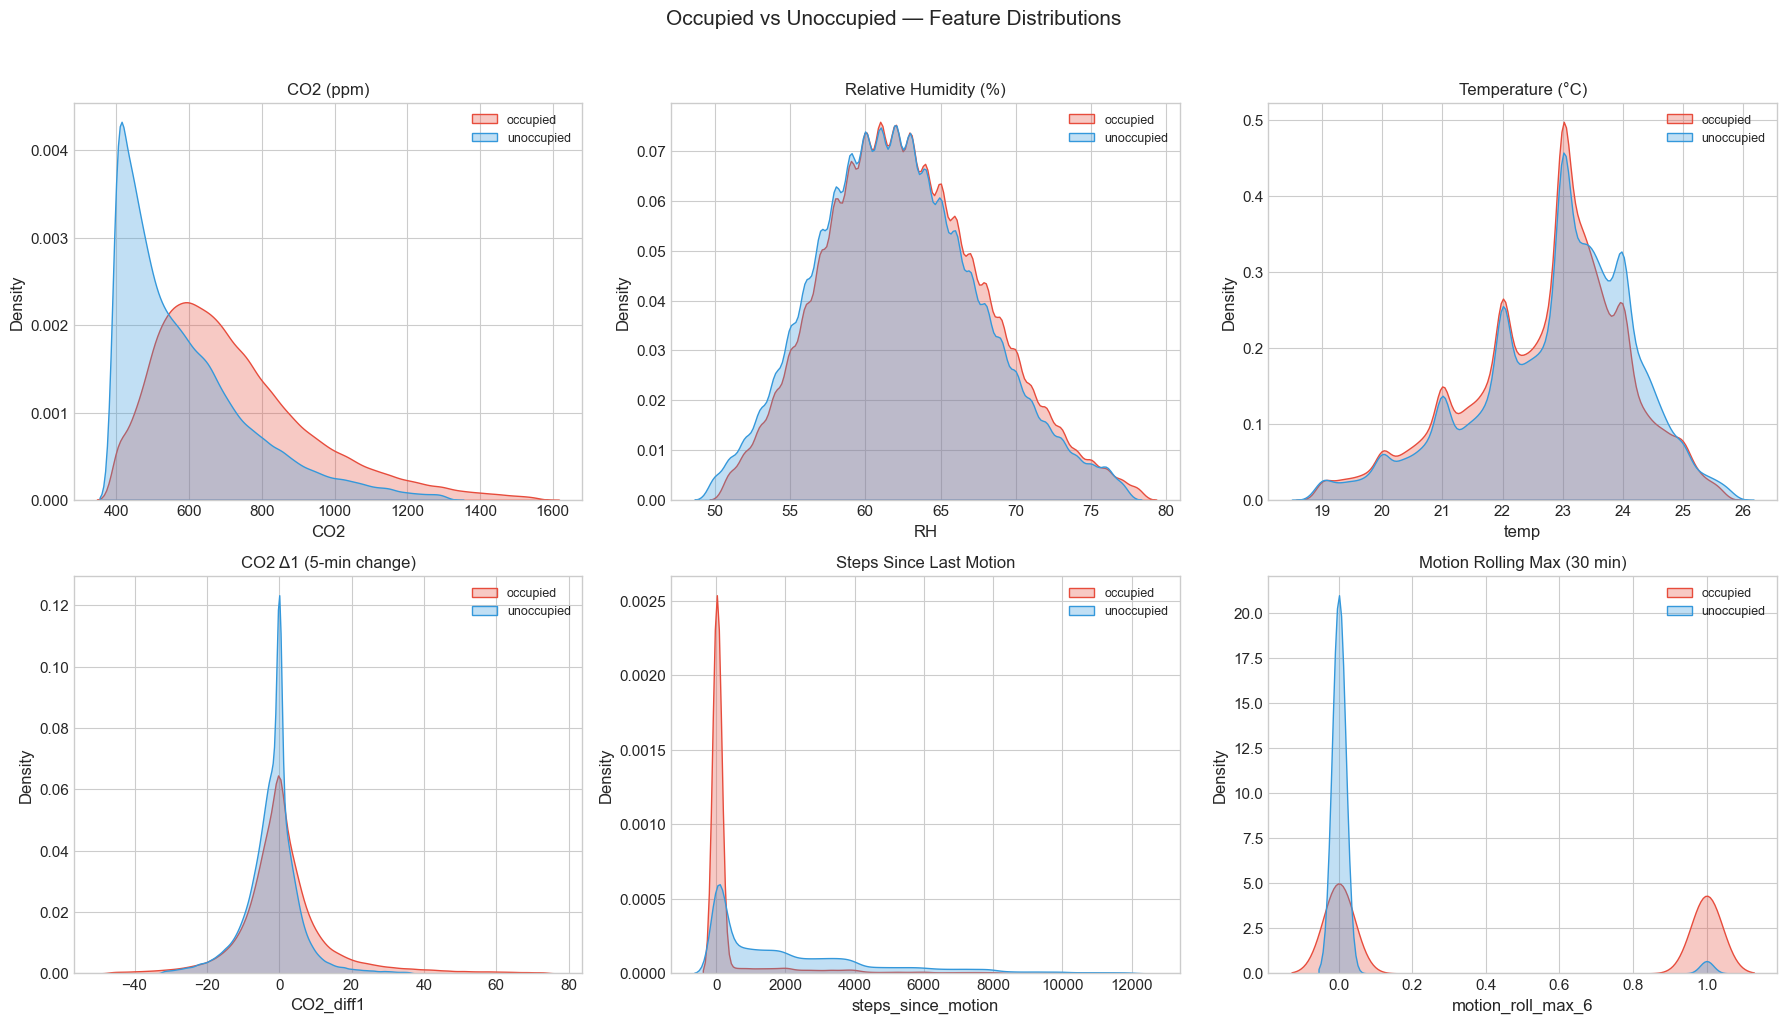

3342

In [8]:
plot_feats = ['CO2', 'RH', 'temp', 'CO2_diff1', 'steps_since_motion', 'motion_roll_max_6']
plot_titles = ['CO2 (ppm)', 'Relative Humidity (%)', 'Temperature (°C)',
               'CO2 Δ1 (5-min change)', 'Steps Since Last Motion', 'Motion Rolling Max (30 min)']

# Subsample for fast plotting
plot_data = compare.sample(n=min(500_000, len(compare)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, (feat, title) in enumerate(zip(plot_feats, plot_titles)):
    ax = axes.flat[idx]
    for label, color in [('occupied', COLORS['occupied']), ('unoccupied', COLORS['unoccupied'])]:
        vals = plot_data.loc[plot_data['occupancy'] == label, feat].dropna()
        if len(vals) > 0:
            # Clip extreme tails for readability
            q01, q99 = vals.quantile(0.01), vals.quantile(0.99)
            vals_clip = vals[(vals >= q01) & (vals <= q99)]
            sns.kdeplot(vals_clip, ax=ax, label=label, color=color, fill=True, alpha=0.3)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle('Occupied vs Unoccupied — Feature Distributions', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

del plot_data
gc.collect()

## 7. Time-Series Room Examples

Visualise CO2, Motion, and Presence over time for selected rooms with clear occupancy transitions.

In [9]:
# Find rooms with good sensor coverage
coverage = (
    eda_feat.groupby('room_area', observed=True)
    .agg(
        n_rows=('timestamp', 'count'),
        co2_cov=('CO2', lambda x: x.notna().mean()),
        motion_cov=('Motion', lambda x: x.notna().mean()),
        presence_cov=('Presence', lambda x: x.notna().mean()),
        occ_ratio=('occ_binary', 'mean'),  # fraction of time occupied
    )
    .query('co2_cov > 0.85 and motion_cov > 0.85 and presence_cov > 0.85')
    .query('occ_ratio > 0.1 and occ_ratio < 0.9')  # rooms with both states
    .sort_values('n_rows', ascending=False)
)

example_rooms = coverage.head(3).index.tolist()
print(f"Example rooms: {example_rooms}")

# Plot each room
for room in example_rooms:
    rdf = eda_feat[eda_feat['room_area'] == room].copy()
    # Take first 3 days for readability
    t_start = rdf['timestamp'].min()
    rdf = rdf[rdf['timestamp'] <= t_start + pd.Timedelta(days=3)]

    fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

    # CO2 with occupancy background
    ax0 = axes[0]
    ax0.plot(rdf['timestamp'], rdf['CO2'], color='#2c3e50', lw=1, label='CO2')
    # shade occupied periods
    occ_mask = rdf['occupancy'] == 'occupied'
    ax0.fill_between(rdf['timestamp'], ax0.get_ylim()[0], ax0.get_ylim()[1],
                     where=occ_mask, alpha=0.15, color=COLORS['occupied'], label='occupied')
    ax0.set_ylabel('CO2 (ppm)')
    ax0.legend(loc='upper right', fontsize=9)
    ax0.set_title(f'{room} — 3-day sensor timeline', fontsize=13)

    # Motion
    ax1 = axes[1]
    ax1.bar(rdf['timestamp'], rdf['Motion'].fillna(0), width=0.003, color='#27ae60', alpha=0.7)
    ax1.set_ylabel('Motion')
    ax1.set_ylim(-0.1, 1.5)

    # Presence state
    ax2 = axes[2]
    ax2.step(rdf['timestamp'], rdf['Presence'].fillna(-1), where='post', color='#8e44ad', lw=1.5)
    ax2.set_ylabel('Presence')
    ax2.set_xlabel('Time')
    ax2.set_yticks([0, 1, 3, 4])
    ax2.set_yticklabels(['0 (empty)', '1 (occupied)', '3 (CO2 off)', '4 (Motion off)'])

    plt.tight_layout()
    plt.show()

Example rooms: []


## 8. Edge Cases & Practical Interpretation

### What a typical **occupied** room looks like:
- `Presence == 1` is active
- Recent motion detected (`motion_roll_max_6 > 0`, low `steps_since_motion`)
- Higher CO2 (typically 600–1500 ppm), often rising or fluctuating
- RH and temp may show more short-term variability (guest activity, door opening/closing)

### What a typical **unoccupied** room looks like:
- `Presence == 0`
- No recent motion (high `steps_since_motion`)
- Lower CO2 (often 400–500 ppm), stable or slowly decaying
- RH and temp are smoother, driven by HVAC and outdoor conditions

### Important edge cases:

| Scenario | What happens | Risk |
|:---|:---|:---|
| **Sleeping guest** | Motion goes quiet for hours, but Presence stays 1 and CO2 stays elevated | Naive motion-only models would misclassify as empty |
| **CO2 decay after checkout** | Guest leaves, CO2 takes 30–90 min to drop to baseline | Lag in CO2-based detection → delayed empty classification |
| **Sensor disconnect (3, 4)** | One sensor is offline; remaining sensors may still work but occupancy ground truth is uncertain | Should not be treated as "occupied" or "unoccupied" without confirmation |
| **Brief visit / housekeeping** | Short burst of motion + door open, but not a real "stay" | May create false positive for occupancy |
| **Multi-zone suites** | bedroom + living_room zones — guest may be in one zone only | Need to consider both zones jointly |

---
## 9. Unsupervised Analysis

Use K-means to discover behavioral groups, UMAP and t-SNE for visualization.  
**Important:** Clusters are NOT ground-truth labels — they reveal data structure.

In [10]:
# === Prepare feature matrix for clustering ===

cluster_features = [
    'RH', 'CO2', 'temp',
    'RH_diff1', 'CO2_diff1', 'temp_diff1',
    'motion_roll_max_6', 'presence_roll_max_6',
    'steps_since_motion', 'steps_since_presence',
    'hour_sin', 'hour_cos',
]

cluster_df = eda_feat.dropna(subset=cluster_features).copy()
print(f"Rows usable for clustering: {len(cluster_df):,} / {len(eda_feat):,}")

# Subsample for manageability
N_KMEANS = min(500_000, len(cluster_df))
sample_km = cluster_df.sample(n=N_KMEANS, random_state=42)

X = sample_km[cluster_features].astype('float32').to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix for K-means: {X_scaled.shape}")

Rows usable for clustering: 2,247,726 / 10,688,832
Feature matrix for K-means: (500000, 12)


  k=2  silhouette=0.1987


  k=3  silhouette=0.1663


  k=4  silhouette=0.1691


  k=5  silhouette=0.1508


  k=6  silhouette=0.1429


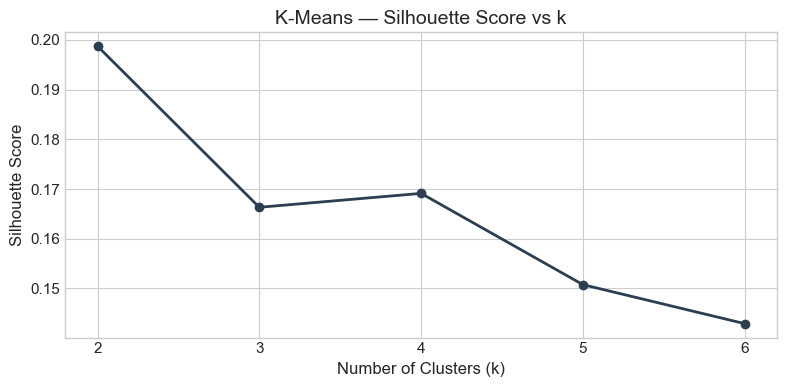


Best k by silhouette: 2 (score=0.1987)


In [11]:
# === K-Means: try k=2..6, evaluate silhouette score ===

K_RANGE = range(2, 7)
silhouette_scores = {}
km_models = {}

# Use a smaller subsample for silhouette (expensive to compute)
sil_idx = np.random.RandomState(42).choice(len(X_scaled), size=min(50_000, len(X_scaled)), replace=False)

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42, max_iter=300)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled[sil_idx], labels[sil_idx], sample_size=None)
    silhouette_scores[k] = sil
    km_models[k] = (km, labels)
    print(f"  k={k}  silhouette={sil:.4f}")

# Plot silhouette
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), 'o-', color='#2c3e50', lw=2)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('K-Means — Silhouette Score vs k')
ax.set_xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

# Choose best k
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest k by silhouette: {best_k} (score={silhouette_scores[best_k]:.4f})")

=== Cluster Feature Profiles ===


,RH,CO2,temp,RH_diff1,CO2_diff1,temp_diff1,motion_roll_max_6,presence_roll_max_6,steps_since_motion,steps_since_presence,hour_sin,hour_cos
cluster,,,,,,,,,,,,
0,62.720001,740.090027,22.75,0.01,0.47,-0.00,0.45,1.00,32.110001,0.220000,0.08,-0.0
1,61.500000,514.010010,23.33,-0.03,-1.93,0.01,0.00,0.01,231.550003,100.559998,-0.28,0.0



=== Occupancy Distribution per Cluster ===


occupancy,occupied,sensor_disconnected,unoccupied
cluster,,,
0,0.936,0.008,0.056
1,0.008,0.001,0.991


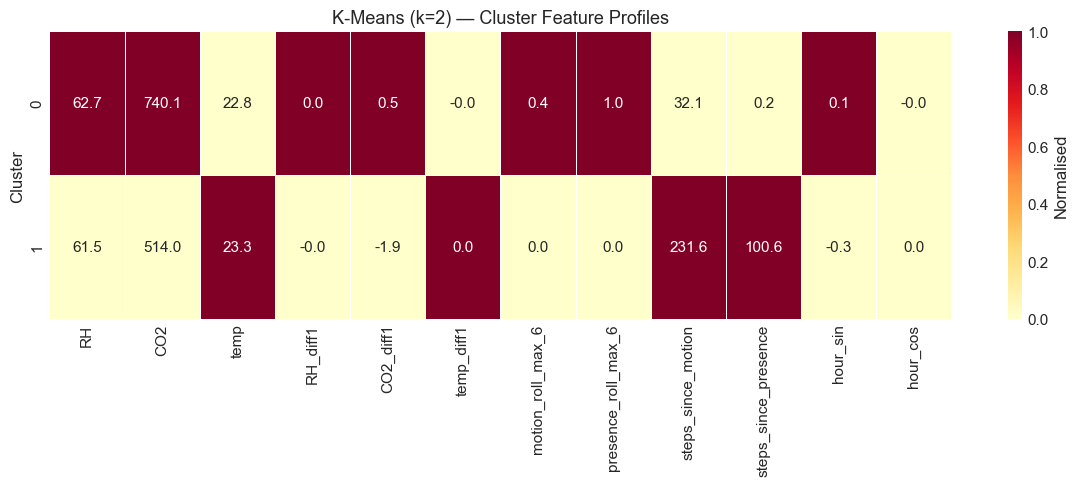

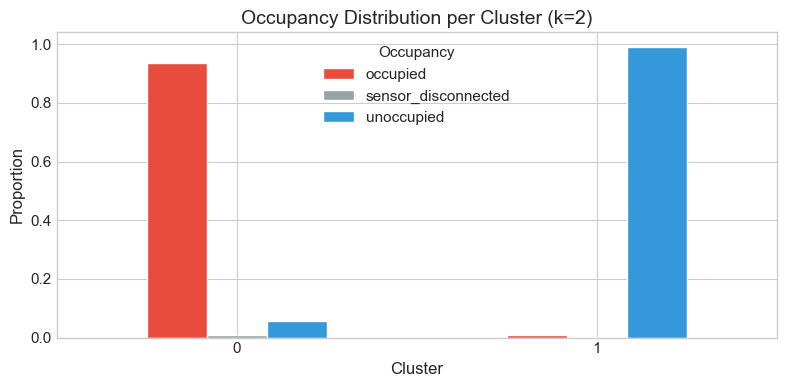

In [12]:
# === Cluster profiling ===

best_km, best_labels = km_models[best_k]
sample_km = sample_km.copy()
sample_km['cluster'] = best_labels

# Feature means per cluster
profile = sample_km.groupby('cluster')[cluster_features].mean().round(2)
print("=== Cluster Feature Profiles ===")
display(profile)

# Occupancy distribution per cluster
if 'occupancy' in sample_km.columns:
    occ_dist = pd.crosstab(sample_km['cluster'], sample_km['occupancy'], normalize='index').round(3)
    print("\n=== Occupancy Distribution per Cluster ===")
    display(occ_dist)

# Heatmap of cluster profiles
fig, ax = plt.subplots(figsize=(12, 5))
# Normalise each feature to [0,1] for visual comparison
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)
sns.heatmap(profile_norm, annot=profile.values, fmt='.1f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Normalised'})
ax.set_title(f'K-Means (k={best_k}) — Cluster Feature Profiles', fontsize=13)
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

# Occupancy bar chart per cluster
if 'occupancy' in sample_km.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    occ_dist.plot.bar(ax=ax, color=[COLORS.get(c, '#95a5a6') for c in occ_dist.columns],
                      edgecolor='white')
    ax.set_title(f'Occupancy Distribution per Cluster (k={best_k})')
    ax.set_ylabel('Proportion')
    ax.set_xlabel('Cluster')
    ax.legend(title='Occupancy')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

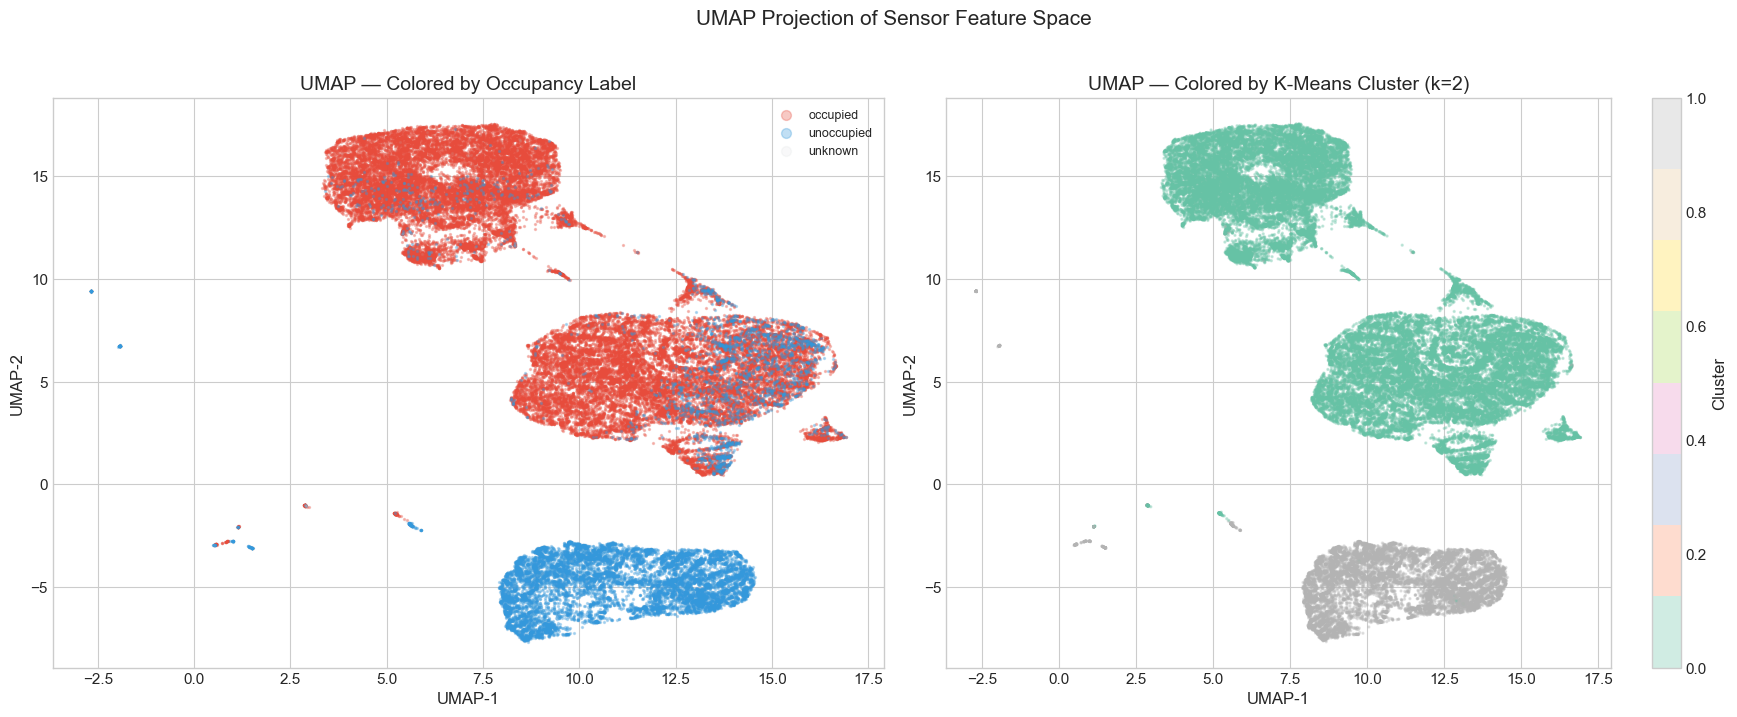

In [13]:
# === UMAP Visualization ===

N_UMAP = min(50_000, len(X_scaled))
umap_idx = np.random.RandomState(42).choice(len(X_scaled), size=N_UMAP, replace=False)
X_umap = X_scaled[umap_idx]
labels_umap = best_labels[umap_idx]

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
emb_umap = reducer.fit_transform(X_umap)

# Plot: colored by occupancy label
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (a) By occupancy
ax = axes[0]
occ_labels_umap = sample_km.iloc[umap_idx]['occupancy'].values
for label, color in COLORS.items():
    mask = occ_labels_umap == label
    if mask.sum() > 0:
        ax.scatter(emb_umap[mask, 0], emb_umap[mask, 1],
                   c=color, label=label, s=2, alpha=0.3)
# NaN occupancy
mask_na = pd.isna(occ_labels_umap)
if mask_na.sum() > 0:
    ax.scatter(emb_umap[mask_na, 0], emb_umap[mask_na, 1],
               c='#bdc3c7', label='unknown', s=2, alpha=0.1)
ax.set_title('UMAP — Colored by Occupancy Label')
ax.legend(markerscale=5, fontsize=9)

# (b) By K-means cluster
ax = axes[1]
scatter = ax.scatter(emb_umap[:, 0], emb_umap[:, 1],
                     c=labels_umap, cmap='Set2', s=2, alpha=0.3)
ax.set_title(f'UMAP — Colored by K-Means Cluster (k={best_k})')
plt.colorbar(scatter, ax=ax, label='Cluster')

for ax in axes:
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')

fig.suptitle('UMAP Projection of Sensor Feature Space', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

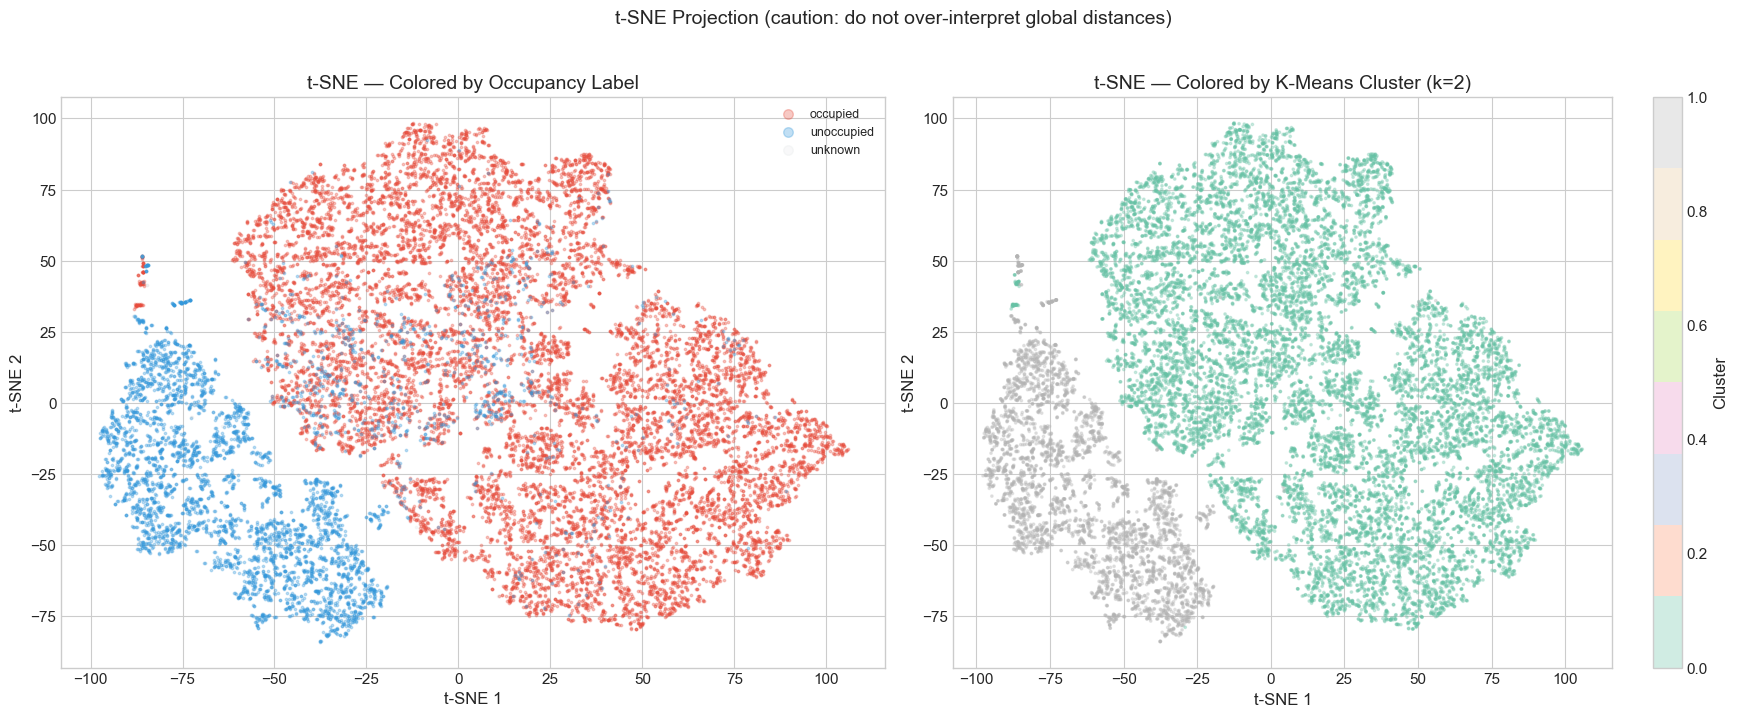


Note: t-SNE preserves local structure well but global distances are NOT meaningful.
Overlap between occupied/unoccupied in t-SNE does NOT mean they are inseparable —
it may reflect transitional states or feature ambiguity at those points.


In [14]:
# === t-SNE Visualization ===

N_TSNE = min(20_000, len(X_scaled))
tsne_idx = np.random.RandomState(42).choice(len(X_scaled), size=N_TSNE, replace=False)
X_tsne = X_scaled[tsne_idx]
labels_tsne = best_labels[tsne_idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, learning_rate='auto')
emb_tsne = tsne.fit_transform(X_tsne)

# Plot: colored by occupancy label and cluster
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (a) By occupancy
ax = axes[0]
occ_labels_tsne = sample_km.iloc[tsne_idx]['occupancy'].values
for label, color in COLORS.items():
    mask = occ_labels_tsne == label
    if mask.sum() > 0:
        ax.scatter(emb_tsne[mask, 0], emb_tsne[mask, 1],
                   c=color, label=label, s=3, alpha=0.3)
mask_na = pd.isna(occ_labels_tsne)
if mask_na.sum() > 0:
    ax.scatter(emb_tsne[mask_na, 0], emb_tsne[mask_na, 1],
               c='#bdc3c7', label='unknown', s=3, alpha=0.1)
ax.set_title('t-SNE — Colored by Occupancy Label')
ax.legend(markerscale=4, fontsize=9)

# (b) By K-means cluster
ax = axes[1]
scatter = ax.scatter(emb_tsne[:, 0], emb_tsne[:, 1],
                     c=labels_tsne, cmap='Set2', s=3, alpha=0.3)
ax.set_title(f't-SNE — Colored by K-Means Cluster (k={best_k})')
plt.colorbar(scatter, ax=ax, label='Cluster')

for ax in axes:
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

fig.suptitle('t-SNE Projection (caution: do not over-interpret global distances)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nNote: t-SNE preserves local structure well but global distances are NOT meaningful.")
print("Overlap between occupied/unoccupied in t-SNE does NOT mean they are inseparable —")
print("it may reflect transitional states or feature ambiguity at those points.")

---
## 10. Summary & Key Findings

### Cleaning Summary
- The preprocessing pipeline classified ~53M long-format rows into quality flags.
- The majority of values were either `single_candidate_misplaced` (reassigned conservatively) or `matched_original`.
- About 20% of values were `multi_candidate_ambiguous` (set to null — conservative approach).
- Rolling MAD detected outliers primarily in `temp` (12.6%), `CO2` (8.6%), and `RH` (8.5%).
- Missing values were imputed using interpolation (short gaps) + rolling median (longer gaps) for continuous sensors, and ffill/bfill for discrete sensors.

### Occupied vs Unoccupied Patterns

| Feature | Occupied | Unoccupied |
|:---|:---|:---|
| CO2 | Higher (typically 600–1500 ppm), more variable | Lower (400–500 ppm), stable |
| CO2 trend (diff1) | Positive or fluctuating | Near zero or slowly declining |
| Motion | Recent activity detected | No recent activity |
| steps_since_motion | Low (0–10) | High (50+) |
| RH & temp | More short-term variability | Smoother, HVAC-driven |

### Unsupervised Insights
- K-means discovers behavioral groups that **correlate with** but are **not identical to** occupancy labels.
- Typical cluster interpretation:
  - **Occupied-like cluster:** high CO2, recent motion, low steps_since_motion
  - **Unoccupied-like cluster:** low CO2, no motion, high steps_since_motion
  - **Transitional cluster(s):** intermediate values — check-in/check-out periods, sleeping guests, CO2 decay phases
- UMAP shows moderate separation between occupied/unoccupied, confirming feature discriminability.
- t-SNE shows local cluster structure. Overlap regions represent ambiguous/transitional states.

### Key Takeaways for Modeling
1. **CO2 and Motion are the strongest occupancy signals.** CO2 level + CO2 trend + recent motion provide good discriminative power.
2. **Presence (ground truth) is reliable** for labeled data. Use it as the primary target for supervised models.
3. **Sleeping guests are an important edge case** — low motion but still occupied. CO2 level and humidity may help distinguish.
4. **Sensor disconnection states (3, 4)** should be handled carefully — exclude from training or treat as a separate class.
5. **Temporal features (hour, is_night) add value** — occupancy patterns correlate with time of day.